<div align="center">
<img width="80%" src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"/>

<br><br>

<img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" alt="Python" width="80" height="80"/>

<h1 style="font-size: 2.5em; color: #e6e6e6; margin: 10px 0;">
  Modelo ao Deploy
</h1>

<h2 style="font-size: 1.8em; color: #e6e6e6; margin: 10px 0;">
  Diagnostico de Falhas em Motores Industriais
</h2>

<h3 style="color: #a8b2d1; font-weight: 400; margin: 10px 0;">
  Modulo 01: Treinamento do Modelo de Classificacao
</h3>

<h4 style="color: #a8b2d1; font-weight: 400; margin: 10px 0;">
  PhD. Julles Mitoura
</h4>

<p style="margin: 10px 0;">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white" alt="Python"/>
  <img src="https://img.shields.io/badge/scikit--learn-F7931E?style=for-the-badge&logo=scikit-learn&logoColor=white" alt="scikit-learn"/>
  <img src="https://img.shields.io/badge/Alura-0078D4?style=for-the-badge&logo=&logoColor=white" alt="Alura"/>
</p>

<img width="80%" src="https://user-images.githubusercontent.com/73097560/115834477-dbab4500-a447-11eb-908a-139a6edaec5c.gif"/>

</div>

## 1. Imports

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.functions.database import load_data, load_failure_types
from src.functions import model as model_service
from src.utils.preprocessing import engineer_features, prepare_dataset, FEATURE_COLS


## 2. Carregamento e Feature Engineering

In [2]:
df_raw = load_data()
label_map = load_failure_types()
label_names = [label_map[i] for i in sorted(label_map)]

df = engineer_features(df_raw)
print(f'Shape apos feature engineering: {df.shape}')
print(f'Features criadas: {FEATURE_COLS}')
df[FEATURE_COLS].describe().round(2)

Shape apos feature engineering: (30000, 15)
Features criadas: ['rotacao_rpm', 'vibracao_mm_s', 'temperatura_c', 'corrente_a', 'rotacao_mean', 'vibracao_std', 'temperatura_max', 'corrente_mean', 'vibracao_por_rotacao']


,rotacao_rpm,vibracao_mm_s,temperatura_c,corrente_a,rotacao_mean,vibracao_std,temperatura_max,corrente_mean,vibracao_por_rotacao
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,1769.70,3.02,69.43,12.51,1769.70,0.40,72.41,12.51,0.00
std,59.31,1.29,6.85,1.35,53.73,0.24,6.69,1.24,0.00
min,1358.73,0.65,52.28,8.08,1396.47,0.00,56.71,9.27,0.00
25%,1735.35,2.30,64.46,11.56,1734.13,0.28,67.61,11.61,0.00
50%,1777.40,2.75,69.52,12.45,1781.23,0.37,72.59,12.45,0.00
75%,1811.01,3.29,73.49,13.39,1810.03,0.47,76.23,13.38,0.00
max,2018.43,13.50,108.06,19.74,1880.44,4.62,108.06,18.95,0.01


## 3. Split

In [3]:
X_train, X_test, y_train, y_test = prepare_dataset(df)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print("Distribuicao no treino:")
print(y_train.value_counts().sort_index().to_string())

Treino: 24000 amostras
Teste:  6000 amostras
Distribuicao no treino:
falha
0    21033
1      964
2     1374
3      629


## 4. Validação Cruzada (StratifiedKFold)

Estimativa robusta de performance com 5 folds estratificados — garante que a proporção de cada classe seja mantida em todos os folds.

In [4]:
cv_results = model_service.cross_validate_model(X_train, y_train, cv=5)

print(f"Accuracy : {cv_results['accuracy_mean']:.4f} ± {cv_results['accuracy_std']:.4f}")
print(f"F1 Macro : {cv_results['f1_macro_mean']:.4f} ± {cv_results['f1_macro_std']:.4f}")

Accuracy : 0.9767 ± 0.0018
F1 Macro : 0.9260 ± 0.0065


## 5. Otimização de Hiperparâmetros (RandomizedSearchCV)

Busca aleatória sobre o espaço de hiperparâmetros do Random Forest, otimizando F1 Macro com 5-fold CV estratificado.

In [5]:
best_model, best_params, best_cv_score = model_service.tune_hyperparameters(
    X_train, y_train, n_iter=30, cv=5
)

print(f"Melhor F1 Macro (CV): {best_cv_score:.4f}")
print("Melhores hiperparâmetros:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhor F1 Macro (CV): 0.9290
Melhores hiperparâmetros:
  clf__n_estimators: 200
  clf__min_samples_split: 2
  clf__min_samples_leaf: 1
  clf__max_features: 0.3
  clf__max_depth: None


## 6. Treinamento

In [6]:
# Usa o pipeline otimizado encontrado na seção 5
pipeline = best_model
pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


## 7. Avaliacao

In [7]:
results = model_service.evaluate(pipeline, X_test, y_test, label_names=label_names)

print(f"Accuracy : {results['accuracy']:.4f}")
print(f"F1 Macro : {results['f1_macro']:.4f}")
print("\nClassification Report:")
print(results['classification_report'])

Accuracy : 0.9777
F1 Macro : 0.9293

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.98      0.99      0.99      5258
Desbalanceamento       0.96      0.88      0.92       241
Superaquecimento       0.91      0.84      0.87       344
  Falha mecanica       0.92      0.96      0.94       157

        accuracy                           0.98      6000
       macro avg       0.94      0.92      0.93      6000
    weighted avg       0.98      0.98      0.98      6000



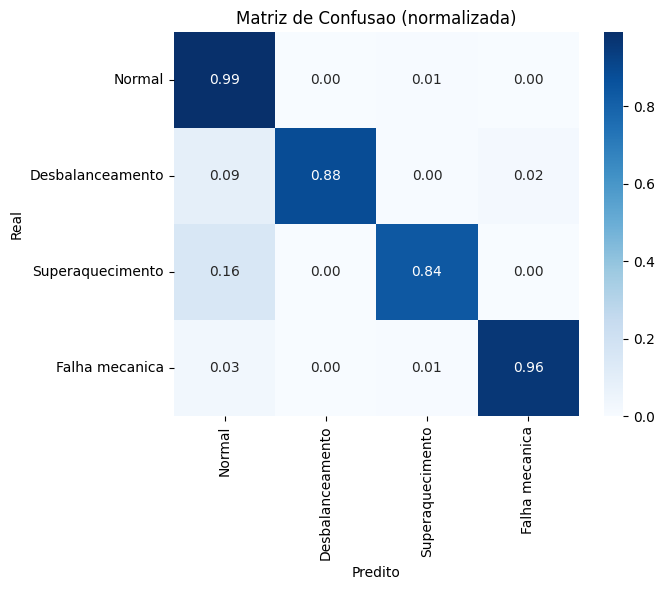

In [8]:
cm = results["confusion_matrix"]
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_title("Matriz de Confusao (normalizada)")
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()


## 8. Importancia das Features

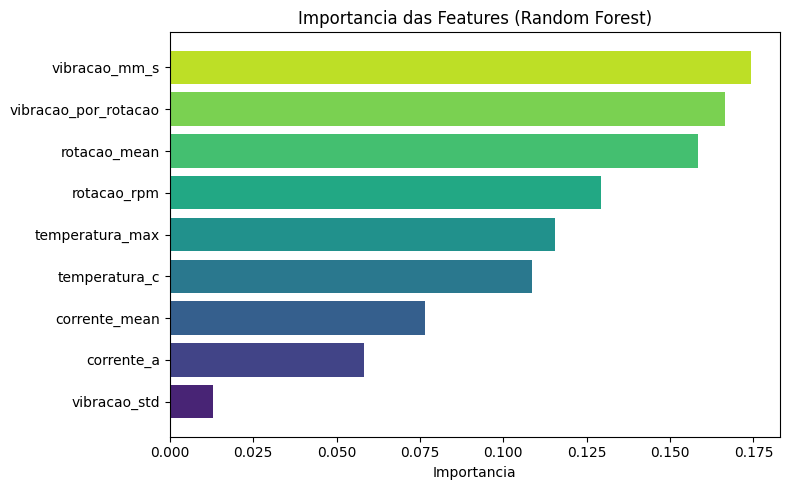

In [9]:
clf = pipeline.named_steps["clf"]
importances = clf.feature_importances_
idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([FEATURE_COLS[i] for i in idx], importances[idx],
        color=sns.color_palette("viridis", len(idx)))
ax.set_title("Importancia das Features (Random Forest)")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()


## 9. Visualizacao PCA das Predicoes

Reduzimos as features para 2 componentes e comparamos as classes reais com as predicoes de cada modelo. Erros de classificacao aparecem como pontos na cor errada.

Variancia explicada: 55.4%


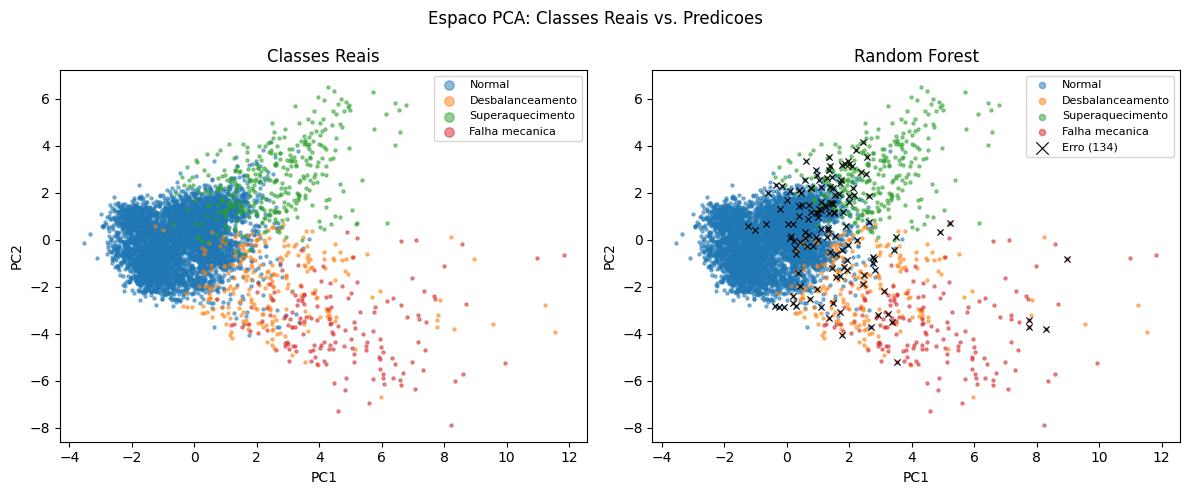

In [10]:
from sklearn.decomposition import PCA

X_test_scaled = pipeline.named_steps["scaler"].transform(X_test)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_test_scaled)

print(f"Variancia explicada: {pca.explained_variance_ratio_.sum():.1%}")

pca_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
pca_df["real"]     = y_test.values
pca_df["pred_rf"]  = pipeline.predict(X_test)

palette = dict(zip(label_names, sns.color_palette("tab10", 4)))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes, ["real", "pred_rf"], ["Classes Reais", "Random Forest"]):
    for classe_idx, group in pca_df.groupby(col):
        nome = label_map[classe_idx]
        ax.scatter(group["PC1"], group["PC2"], label=nome, s=5, alpha=0.5, color=palette[nome])
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(markerscale=3, fontsize=8)

erros = pca_df[pca_df["real"] != pca_df["pred_rf"]]
axes[1].scatter(erros["PC1"], erros["PC2"], s=20, color="black", marker="x",
                linewidths=0.8, label=f"Erro ({len(erros)})", zorder=5)
axes[1].legend(markerscale=2, fontsize=8)

plt.suptitle("Espaco PCA: Classes Reais vs. Predicoes")
plt.tight_layout()
plt.show()


## 10. Salvar Modelo

In [11]:
model_service.save(pipeline)
print("Pipeline salvo em models/motor_classifier.joblib")

Pipeline salvo em models/motor_classifier.joblib


## 11. Verificacao do Artefato

In [12]:
artefato = model_service.load()
print("Chaves do artefato:", list(artefato.keys()))
print("Pipeline:", artefato["pipeline"])

sample = X_test.iloc[:3]
predicoes = artefato["pipeline"].predict(sample)
print("Predicoes de exemplo:", [label_map[p] for p in predicoes])


Chaves do artefato: ['pipeline']
Pipeline: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        max_features=0.3, n_estimators=200,
                                        random_state=42))])
Predicoes de exemplo: ['Normal', 'Normal', 'Normal']


## 12. Predicao com o metodo predict

In [29]:
from src.functions.model import predict

artefato = model_service.load()

resultado = predict(
    vars={
        "rotacao_rpm":   1800.0,
        "vibracao_mm_s": 8.5,
        "temperatura_c": 95.0,
        "corrente_a":    18.2,
    },
    artifact=artefato,
    failure_threshold=0.5
)

classe_nome = resultado["falha"]
print(f'Classe predita : {classe_nome}')
print('Probabilidades :')
for codigo, prob in resultado["probabilidades"].items():
    print(f'  - {codigo}: {prob:.2%}')

Classe predita : Superaquecimento
Probabilidades :
  - Normal: 0.50%
  - Desbalanceamento: 36.50%
  - Superaquecimento: 60.00%
  - Falha mecanica: 3.00%
